In [ ]:
!pip install transformers datasets peft accelerate scikit-learn pandas

In [ ]:
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
# load dataset
df = pd.read_csv("cellula toxic data  (1).csv")

# merge text fields into one input
df["text"] = df["query"] + " [SEP] " + df["image descriptions"]


# encode labels to numeric ids
le = LabelEncoder()
df["label"] = le.fit_transform(df["Toxic Category"])
num_labels = len(le.classes_)

In [ ]:
# split train and test with class balance
train_df, test_df = train_test_split(
    df[["text", "label"]],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [ ]:
# convert to hf dataset
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

In [ ]:
# load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# tokenize text
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

In [ ]:
# set pytorch format
train_ds.set_format("torch", columns=["input_ids","attention_mask","label"])
test_ds.set_format("torch", columns=["input_ids","attention_mask","label"])

In [ ]:
# load distilbert classifier
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# define lora config for attention layers
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin","v_lin"]
)

In [ ]:
# attach lora adapters
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


# define evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

trainable params: 744,969 || all params: 67,705,362 || trainable%: 1.1003


In [ ]:
# training arguments (compatible with older transformers)
training_args = TrainingArguments(
    output_dir="./distilbert_lora",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    learning_rate=2e-4,
    logging_steps=50
)


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

trainer.train()

# run evaluation manually
results = trainer.evaluate()
print(results)

Step,Training Loss
50,1.636727
100,0.778168
150,0.355706
200,0.134159
250,0.133259
300,0.145479
350,0.138390
400,0.095505
450,0.110073
500,0.078909


{'eval_loss': 0.1309315711259842, 'eval_accuracy': 0.96, 'eval_f1': 0.9539760582428858, 'eval_runtime': 2.3085, 'eval_samples_per_second': 259.912, 'eval_steps_per_second': 16.461, 'epoch': 4.0}


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "f1_macro": f1_macro
    }


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# get predictions
pred_output = trainer.predict(test_ds)

preds = np.argmax(pred_output.predictions, axis=1)
labels = pred_output.label_ids

# print confusion matrix
print(confusion_matrix(labels, preds))

# detailed per-class report
print(classification_report(labels, preds))


[[ 21   0   0   0   0   0   0   0   0]
 [  0  22   0   0   0   0   0   0   0]
 [  0   0  59   0   0   0   1   0   0]
 [  0   0   0 199   0   0   0   0   0]
 [  0   0   0   0  23   0   0   0   0]
 [  0   0   0   0   0  23   0   0   0]
 [  0   0   0  22   0   0  17   0   0]
 [  0   0   0   1   0   0   0 157   0]
 [  0   0   0   0   0   0   0   0  55]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        22
           2       1.00      0.98      0.99        60
           3       0.90      1.00      0.95       199
           4       1.00      1.00      1.00        23
           5       1.00      1.00      1.00        23
           6       0.94      0.44      0.60        39
           7       1.00      0.99      1.00       158
           8       1.00      1.00      1.00        55

    accuracy                           0.96       600
   macro avg       0.98      0.93      0.95       60

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_ds:
        input_ids = batch["input_ids"].unsqueeze(0).to(model.device)  # Add batch dim and move to GPU
        attention_mask = batch["attention_mask"].unsqueeze(0).to(model.device) # Move to GPU
        labels = batch["label"].unsqueeze(0).to(model.device) # Move to GPU

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

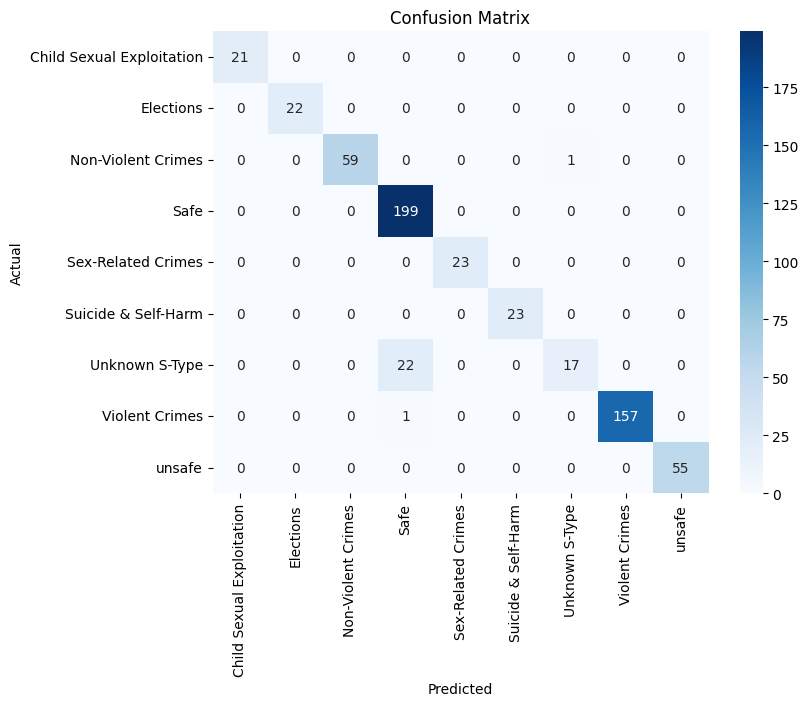

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
report = classification_report(all_labels, all_preds, target_names=le.classes_)
print("Classification Report:\n")
print(report)

Classification Report:

                           precision    recall  f1-score   support

Child Sexual Exploitation       1.00      1.00      1.00        21
                Elections       1.00      1.00      1.00        22
       Non-Violent Crimes       1.00      0.98      0.99        60
                     Safe       0.90      1.00      0.95       199
       Sex-Related Crimes       1.00      1.00      1.00        23
      Suicide & Self-Harm       1.00      1.00      1.00        23
           Unknown S-Type       0.94      0.44      0.60        39
           Violent Crimes       1.00      0.99      1.00       158
                   unsafe       1.00      1.00      1.00        55

                 accuracy                           0.96       600
                macro avg       0.98      0.93      0.95       600
             weighted avg       0.96      0.96      0.95       600



/tmp/ipython-input-3813015584.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=le.classes_, y=f1_scores, palette="viridis")


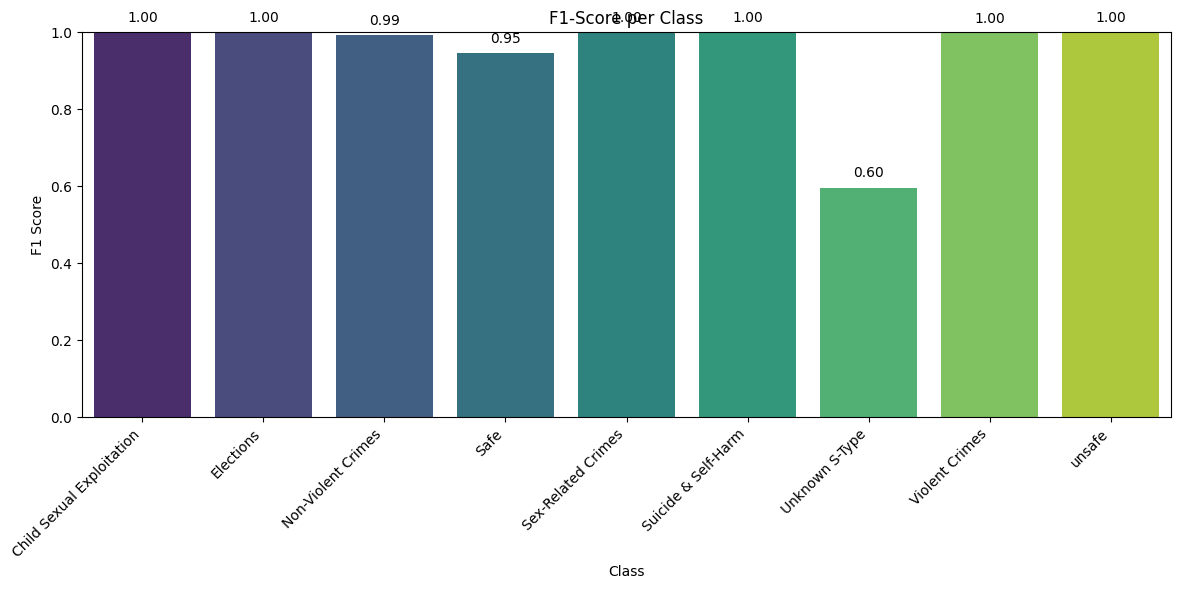

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=le.classes_, y=f1_scores, palette="viridis")


plt.xticks(rotation=45, ha="right")

plt.title("F1-Score per Class")
plt.ylabel("F1 Score")
plt.xlabel("Class")
plt.ylim(0,1)

for i, score in enumerate(f1_scores):
    plt.text(i, score + 0.02, f"{score:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


In [ ]:
accuracy = accuracy_score(all_labels, all_preds)
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")

Overall Accuracy: 0.9600
Weighted F1-Score: 0.9540
